In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('tourism_cleaned_engineered.csv')
df = df.drop(columns=['user_avg_rating', 'attraction_avg_rating'])  # yahan bhi wahi leak-safe rule follow karenge

print(df.shape)
print(df['VisitMode'].value_counts())

(52930, 22)
VisitMode
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [2]:
feature_cols = ['VisitYear', 'VisitMonth', 'AttractionTypeId', 'Continent', 'Region',
                 'Country', 'Rating', 'user_visit_count']

X = df[feature_cols + ['UserId', 'AttractionId']].copy()
y = df['VisitMode']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train distribution:\n", y_train.value_counts(normalize=True))

Train: (42344, 10)  Test: (10586, 10)
Train distribution:
 VisitMode
Couples     0.408464
Family      0.287502
Friends     0.206783
Solo        0.085490
Business    0.011761
Name: proportion, dtype: float64


In [3]:
attraction_avg_rating_map_clf = y_train.index.to_series().map(X_train['Rating'])  # placeholder, fix below

#Rating average per attraction, training data se
attraction_avg_rating_map_clf = X_train.groupby('AttractionId')['Rating'].mean()
global_avg_rating_clf = X_train['Rating'].mean()

X_train['attraction_avg_rating'] = X_train['AttractionId'].map(attraction_avg_rating_map_clf).fillna(global_avg_rating_clf)
X_test['attraction_avg_rating'] = X_test['AttractionId'].map(attraction_avg_rating_map_clf).fillna(global_avg_rating_clf)

X_train = X_train.drop(columns=['UserId', 'AttractionId'])
X_test = X_test.drop(columns=['UserId', 'AttractionId'])

# Country/VisitMode jaisा pattern — Continent/Region drop, sirf Country encode
X_train = X_train.drop(columns=['Continent', 'Region'])
X_test = X_test.drop(columns=['Continent', 'Region'])

X_train_enc = pd.get_dummies(X_train, columns=['Country'], drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=['Country'], drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print("Feature matrix shape:", X_train_enc.shape)

Feature matrix shape: (42344, 157)


In [4]:
# Class weights 
sample_weights = compute_sample_weight('balanced', y_train)

# ===== Model 1: Logistic Regression =====
scaler = StandardScaler()
num_cols = ['VisitYear', 'VisitMonth', 'AttractionTypeId', 'Rating', 'user_visit_count', 'attraction_avg_rating']
X_train_s = X_train_enc.copy(); X_train_s[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_s = X_test_enc.copy(); X_test_s[num_cols] = scaler.transform(X_test_enc[num_cols])

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
print("Logistic Regression:")
print(classification_report(y_test, pred_lr))
print("Macro F1:", f1_score(y_test, pred_lr, average='macro'))

# ===== Model 2: Random Forest =====
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_enc, y_train)
pred_rf = rf.predict(X_test_enc)
print("\nRandom Forest:")
print(classification_report(y_test, pred_rf))
print("Macro F1:", f1_score(y_test, pred_rf, average='macro'))

# ===== Model 3: XGBoost =====
le_map = {c: i for i, c in enumerate(sorted(y.unique()))}
inv_le_map = {v: k for k, v in le_map.items()}
y_train_enc = y_train.map(le_map)
y_test_enc = y_test.map(le_map)

xgb_clf = xgb.XGBClassifier(n_estimators=150, max_depth=6, random_state=42, eval_metric='mlogloss', n_jobs=-1)
xgb_clf.fit(X_train_enc, y_train_enc, sample_weight=sample_weights)
pred_xgb = xgb_clf.predict(X_test_enc)
print("\nXGBoost:")
print(classification_report(y_test_enc, pred_xgb, target_names=[inv_le_map[i] for i in sorted(inv_le_map)]))
print("Macro F1:", f1_score(y_test_enc, pred_xgb, average='macro'))

Logistic Regression:
              precision    recall  f1-score   support

    Business       0.03      0.50      0.06       125
     Couples       0.53      0.34      0.41      4324
      Family       0.41      0.42      0.42      3043
     Friends       0.27      0.08      0.13      2189
        Solo       0.13      0.30      0.18       905

    accuracy                           0.31     10586
   macro avg       0.28      0.33      0.24     10586
weighted avg       0.40      0.31      0.33     10586

Macro F1: 0.24109897209049858

Random Forest:
              precision    recall  f1-score   support

    Business       0.05      0.62      0.10       125
     Couples       0.51      0.56      0.53      4324
      Family       0.59      0.30      0.40      3043
     Friends       0.38      0.11      0.17      2189
        Solo       0.15      0.35      0.21       905

    accuracy                           0.38     10586
   macro avg       0.34      0.39      0.28     10586
weighted a

In [5]:
feat_importance = pd.Series(xgb_clf.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)
print(feat_importance.head(10))

Country_Indonesia         0.122207
Country_Australia         0.038431
Country_Malaysia          0.025709
Country_United States     0.024997
Country_Canada            0.024927
attraction_avg_rating     0.024225
Country_United Kingdom    0.023236
Country_Singapore         0.020765
Country_India             0.019928
AttractionTypeId          0.019674
dtype: float32


In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [150, 250],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}
search = RandomizedSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
                             param_dist, n_iter=4, scoring='f1_macro', cv=3, random_state=42)
search.fit(X_train_enc, y_train_enc, sample_weight=sample_weights)

print("Best params:", search.best_params_)
best_xgb_clf = search.best_estimator_
pred_tuned = best_xgb_clf.predict(X_test_enc)
print("Tuned Macro F1:", f1_score(y_test_enc, pred_tuned, average='macro'))

Best params: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.1}
Tuned Macro F1: 0.3187083864769465


<Figure size 700x600 with 0 Axes>

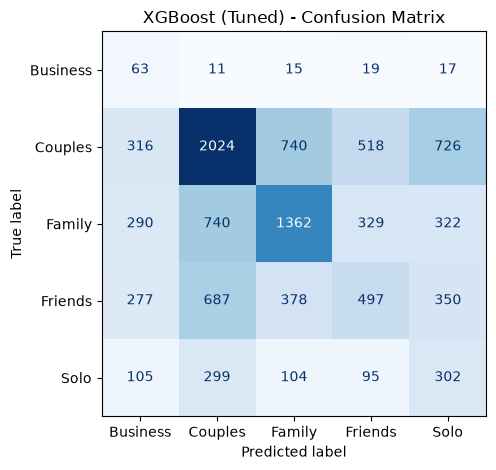

Saved.


In [7]:
cm = confusion_matrix(y_test_enc, pred_tuned)
class_names = [inv_le_map[i] for i in sorted(inv_le_map)]
plt.figure(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', colorbar=False)
plt.title('XGBoost (Tuned) - Confusion Matrix')
plt.tight_layout()
plt.show()

import joblib
joblib.dump(best_xgb_clf, 'best_classification_model.pkl')
joblib.dump(X_train_enc.columns.tolist(), 'classification_feature_columns.pkl')
joblib.dump(le_map, 'visitmode_label_map.pkl')
print("Saved.")

## Classification Summary

**Final model:** XGBoost (tuned), Macro F1 = 0.319 — the best of three models tried (LR 0.241, RF 0.282, XGBoost 0.319).

**Honest limitation:** This is meaningfully weaker than the classification results from earlier capstone projects (which reached 0.83+ Macro F1). Feature importance showed no dominant predictor — the top feature (Country_Indonesia) carries only 12% importance, with signal diffused thinly across dozens of country dummies. This suggests visit mode (Business/Family/Couples/etc.) is largely a personal, subjective choice that isn't strongly determined by the geographic and attraction-level features available here — unlike, say, financial eligibility, which has clear quantitative drivers.

**Business class remains hard to predict** (6% precision even after weighting) simply because it's both rare (1.2%) and not clearly separated from other classes by any available feature — more data on trip purpose or booking context (not present in this dataset) would likely be needed to improve this meaningfully.